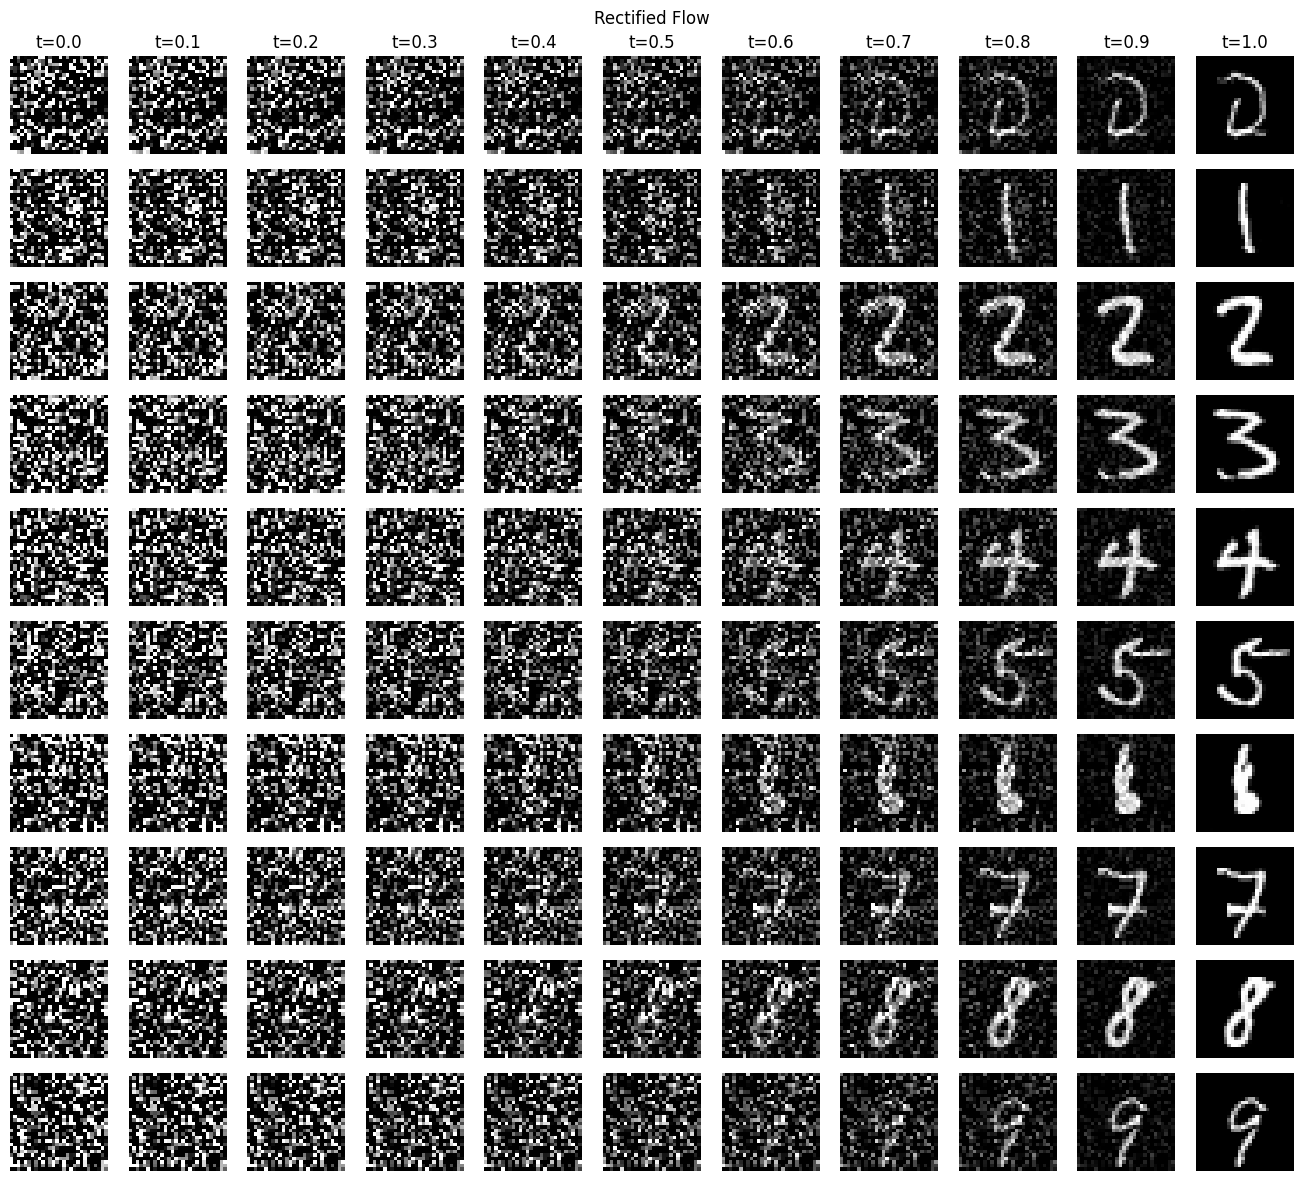

In [8]:
from rectified_flow import RectifiedFlow, RectifiedFlow_VS
from model import MiniUnet
import torch
import numpy as np
import matplotlib.pyplot as plt

rf_checkpoint_path = './checkpoints/v1.1-cfg/miniunet_49.pth'
rf_vs_checkpoint_path = './checkpoints/v1.1-cfg/miniunet_vs_49.pth'
base_channels = 64
step = 50  # number of Euler steps
device = 'mps'

num_cols = 11
col_times = np.linspace(0.0, 1.0, num_cols)
# capture after these step indices (1..step). we also store the initial state at t=0
capture_after = {int(round(t * step)) for t in col_times[1:]}

# load model
model_rf = MiniUnet(base_channels=base_channels)
model_rf.to(device)
model_rf.eval()

model_rf_vs = MiniUnet(base_channels=base_channels)
model_rf_vs.to(device)
model_rf_vs.eval()

# load RectifiedFlow and checkpoint
rf = RectifiedFlow()
model_rf.load_state_dict(torch.load(rf_checkpoint_path, map_location=device)['model'])

rf_vs = RectifiedFlow_VS()
model_rf_vs.load_state_dict(torch.load(rf_vs_checkpoint_path, map_location=device)['model'])

all_mats = []  # [target_digit][start_digit][time_idx][H][W]
with torch.no_grad():
    for target_digit in range(10):
        rows = []
        y_i = torch.tensor([target_digit], dtype=torch.float32, device=device)
        dt = 1.0 / step
        x_t = torch.randn(1, 1, 28, 28).to(device)

        snapshots = [x_t.clone()]
        for j in range(step):
            t = torch.tensor([j * dt], device=device)

            # conditional prediction
            v_pred_cond = model(x=x_t, t=t, y=y_i)
            x_t = rf.euler(x_t, v_pred_cond, dt)

            if (j + 1) in capture_after:
                snapshots.append(x_t.clone())

        # convert snapshots to numpy images in [0, 1]
        row_imgs = [snap[0, 0].clamp(0, 1).cpu().numpy() for snap in snapshots]

        all_mats.append(row_imgs)

# plot
fig, axes = plt.subplots(10, num_cols, figsize=(num_cols * 1.2, 10 * 1.2))
for r in range(10):
    for c in range(num_cols):
        ax = axes[r, c]
        ax.imshow(all_mats[r][c], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if r == 0:
            ax.set_title(f't={col_times[c]:.1f}')
        if c == 0:
            ax.set_ylabel(str(r), rotation=0, labelpad=10, va='center')
fig.suptitle("Rectified Flow")
plt.tight_layout()
plt.show()


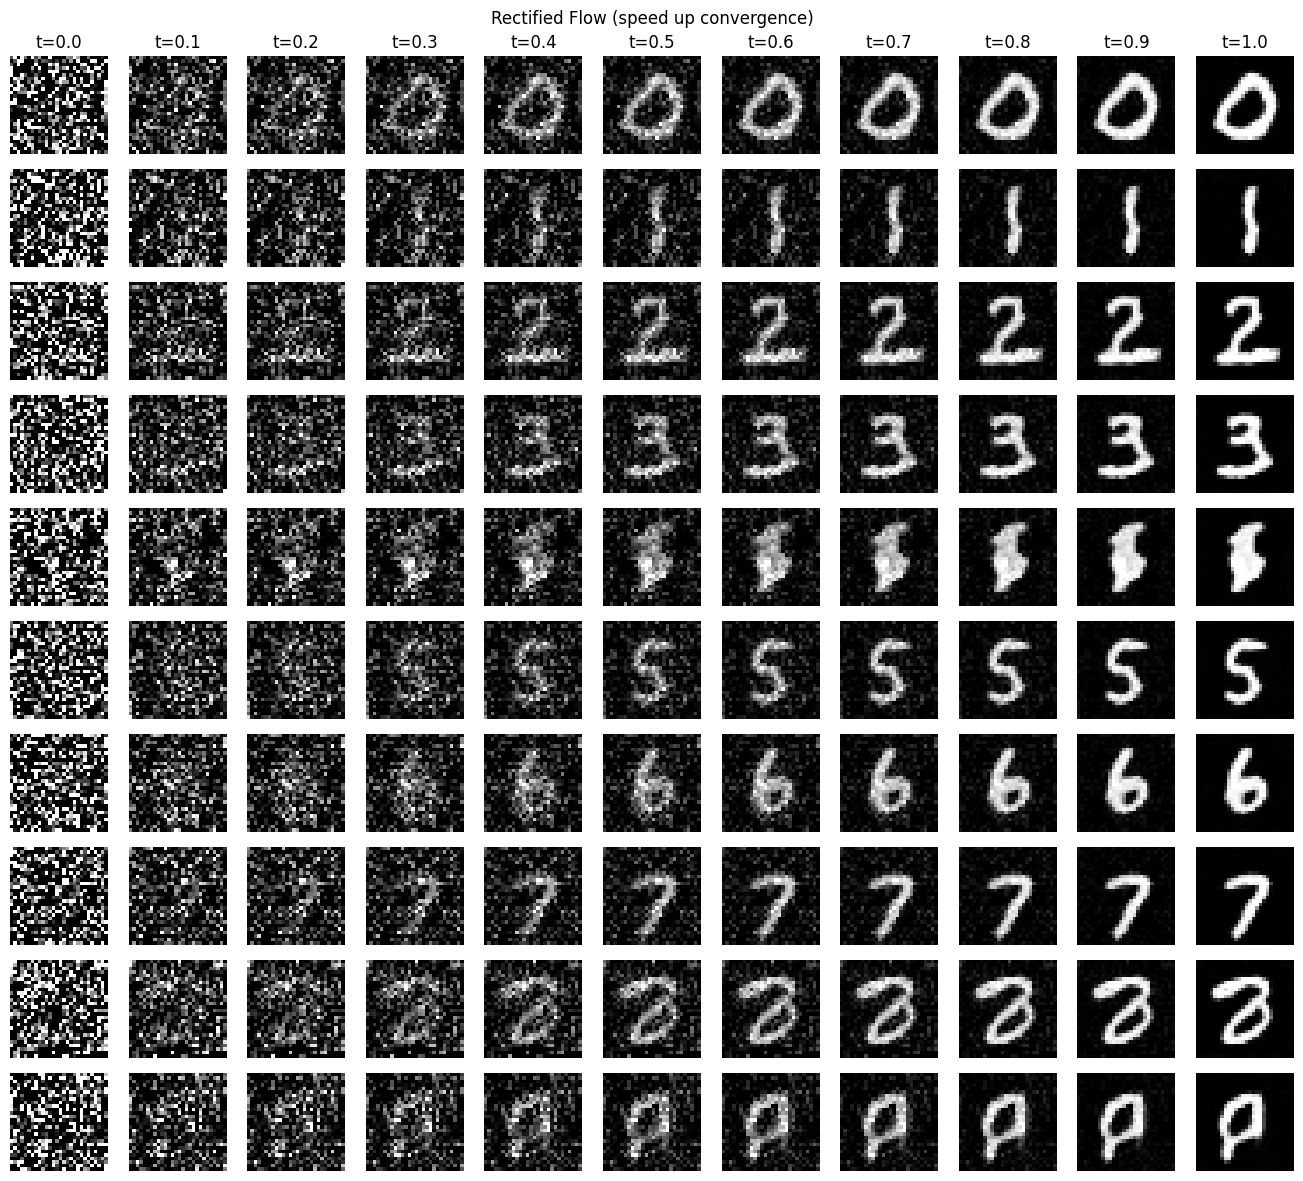

In [9]:
from rectified_flow import RectifiedFlow_VS
from model import MiniUnet
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

checkpoint_path = './checkpoints/v1.1-cfg/miniunet_vs_49.pth'
base_channels = 64
step = 50  # number of Euler steps
cfg_scale = 7.0
device = 'mps'

num_cols = 11
col_times = np.linspace(0.0, 1.0, num_cols)
# capture after these step indices (1..step). we also store the initial state at t=0
capture_after = {int(round(t * step)) for t in col_times[1:]}

# load model
model = MiniUnet(base_channels=base_channels)
model.to(device)
model.eval()

# load RectifiedFlow and checkpoint
rf = RectifiedFlow_VS()
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model'])

all_mats = []  # [target_digit][start_digit][time_idx][H][W]
with torch.no_grad():
    for target_digit in range(10):
        rows = []
        y_i = torch.tensor([target_digit], dtype=torch.float32, device=device)
        dt = 1.0 / step
        x_t = torch.randn(1, 1, 28, 28).to(device)

        snapshots = [x_t.clone()]
        for j in range(step):
            t = torch.tensor([j * dt], device=device)

            # conditional prediction
            v_pred_cond = model(x=x_t, t=t, y=y_i)
            x_t = rf.euler(x_t, v_pred_cond, dt)

            if (j + 1) in capture_after:
                snapshots.append(x_t.clone())

        # convert snapshots to numpy images in [0, 1]
        row_imgs = [snap[0, 0].clamp(0, 1).cpu().numpy() for snap in snapshots]

        all_mats.append(row_imgs)

# plot
fig, axes = plt.subplots(10, num_cols, figsize=(num_cols * 1.2, 10 * 1.2))
for r in range(10):
    for c in range(num_cols):
        ax = axes[r, c]
        ax.imshow(all_mats[r][c], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if r == 0:
            ax.set_title(f't={col_times[c]:.1f}')
        if c == 0:
            ax.set_ylabel(str(r), rotation=0, labelpad=10, va='center')

fig.suptitle("Rectified Flow (speed up convergence)")
plt.tight_layout()
plt.show()


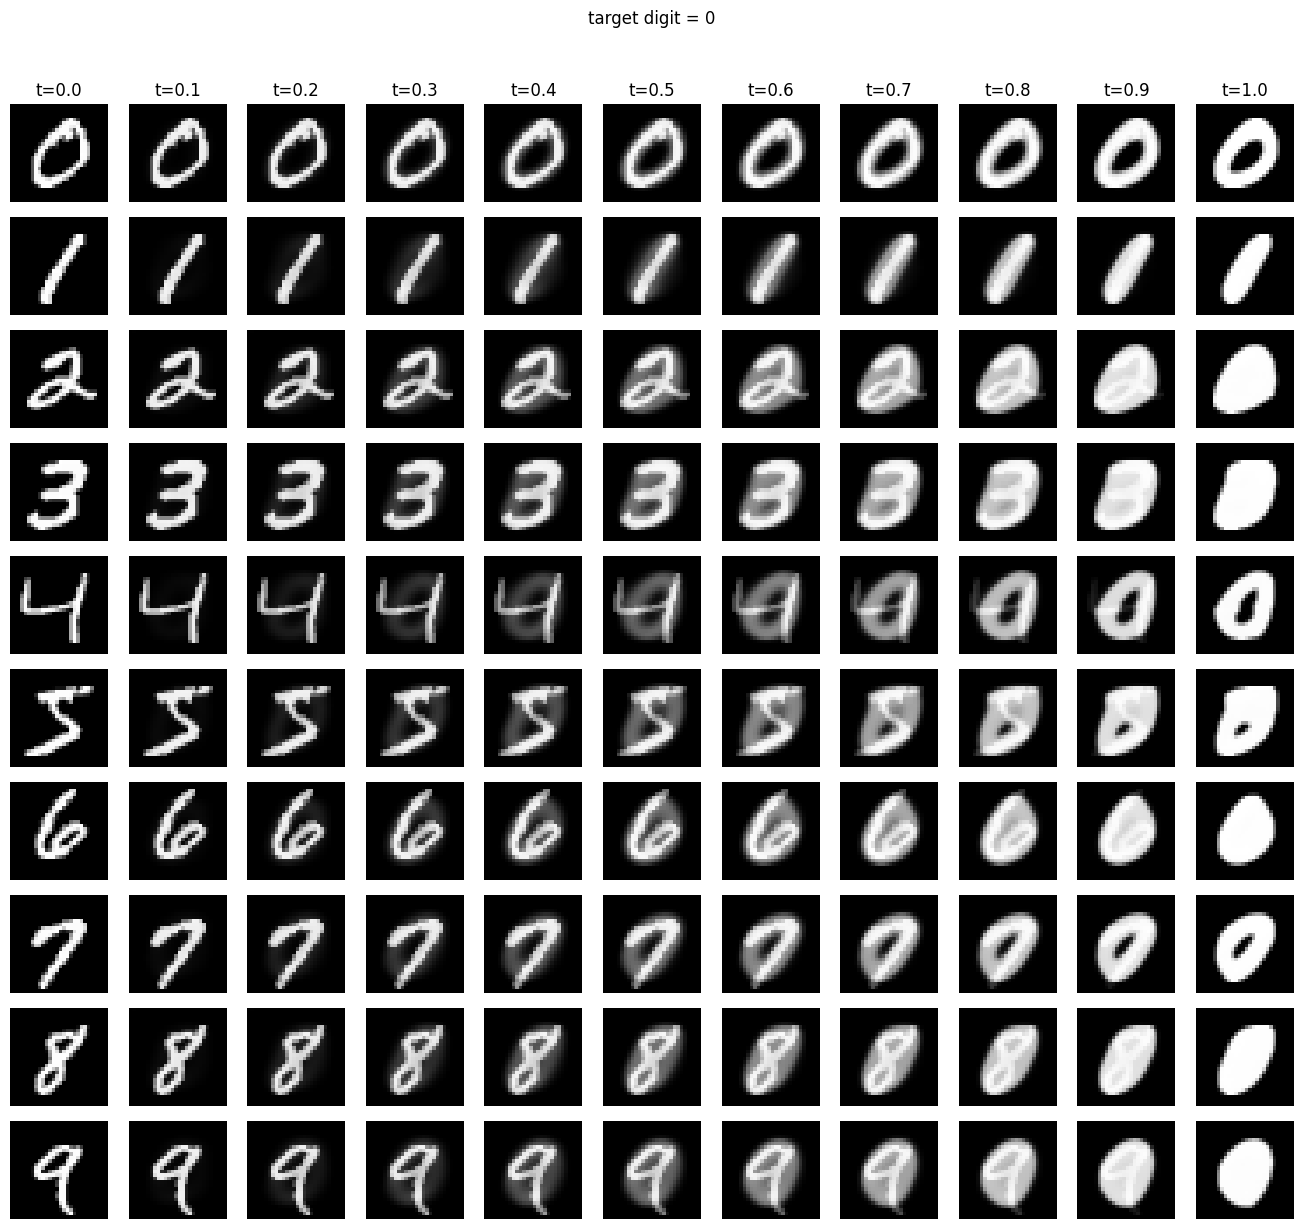

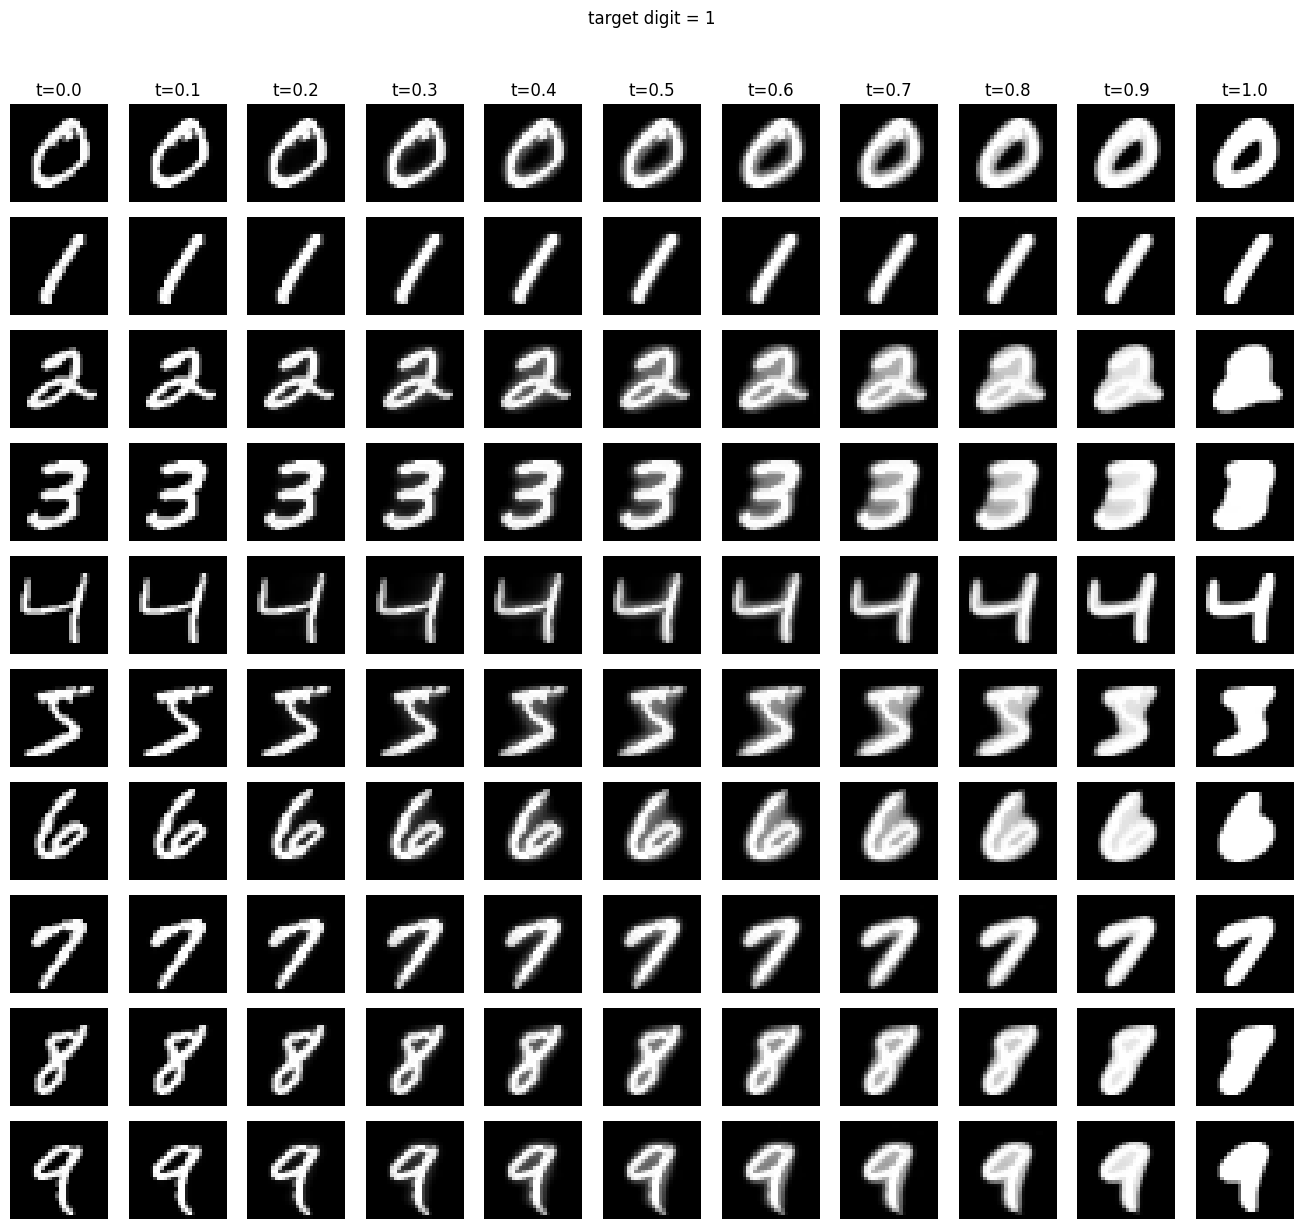

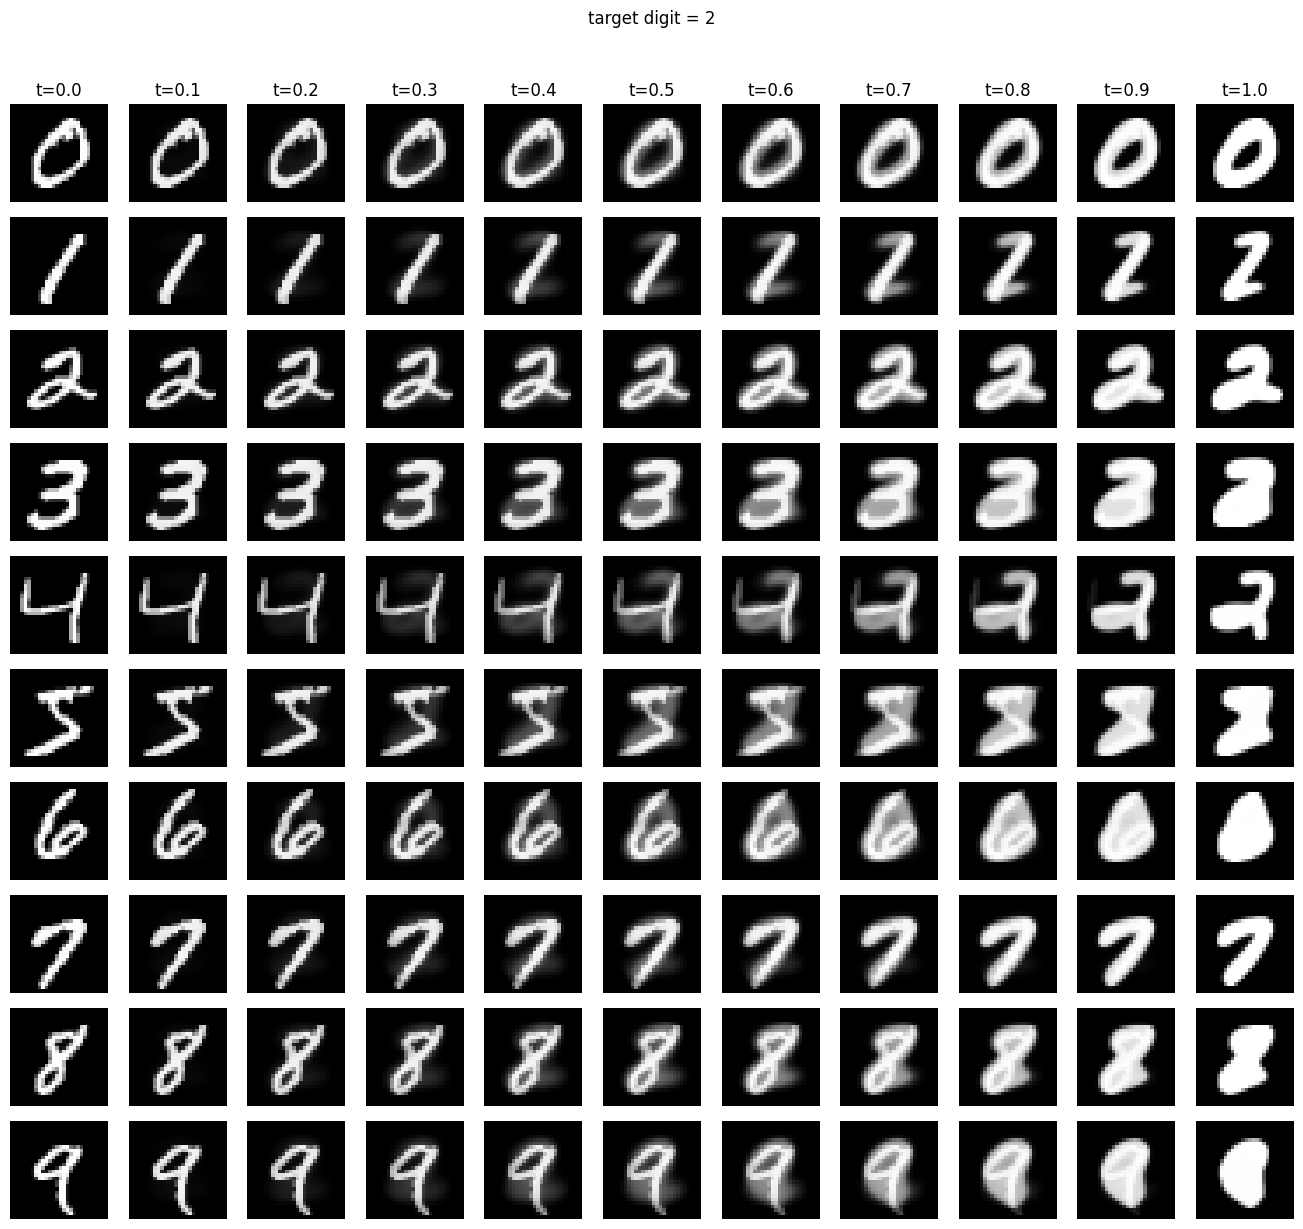

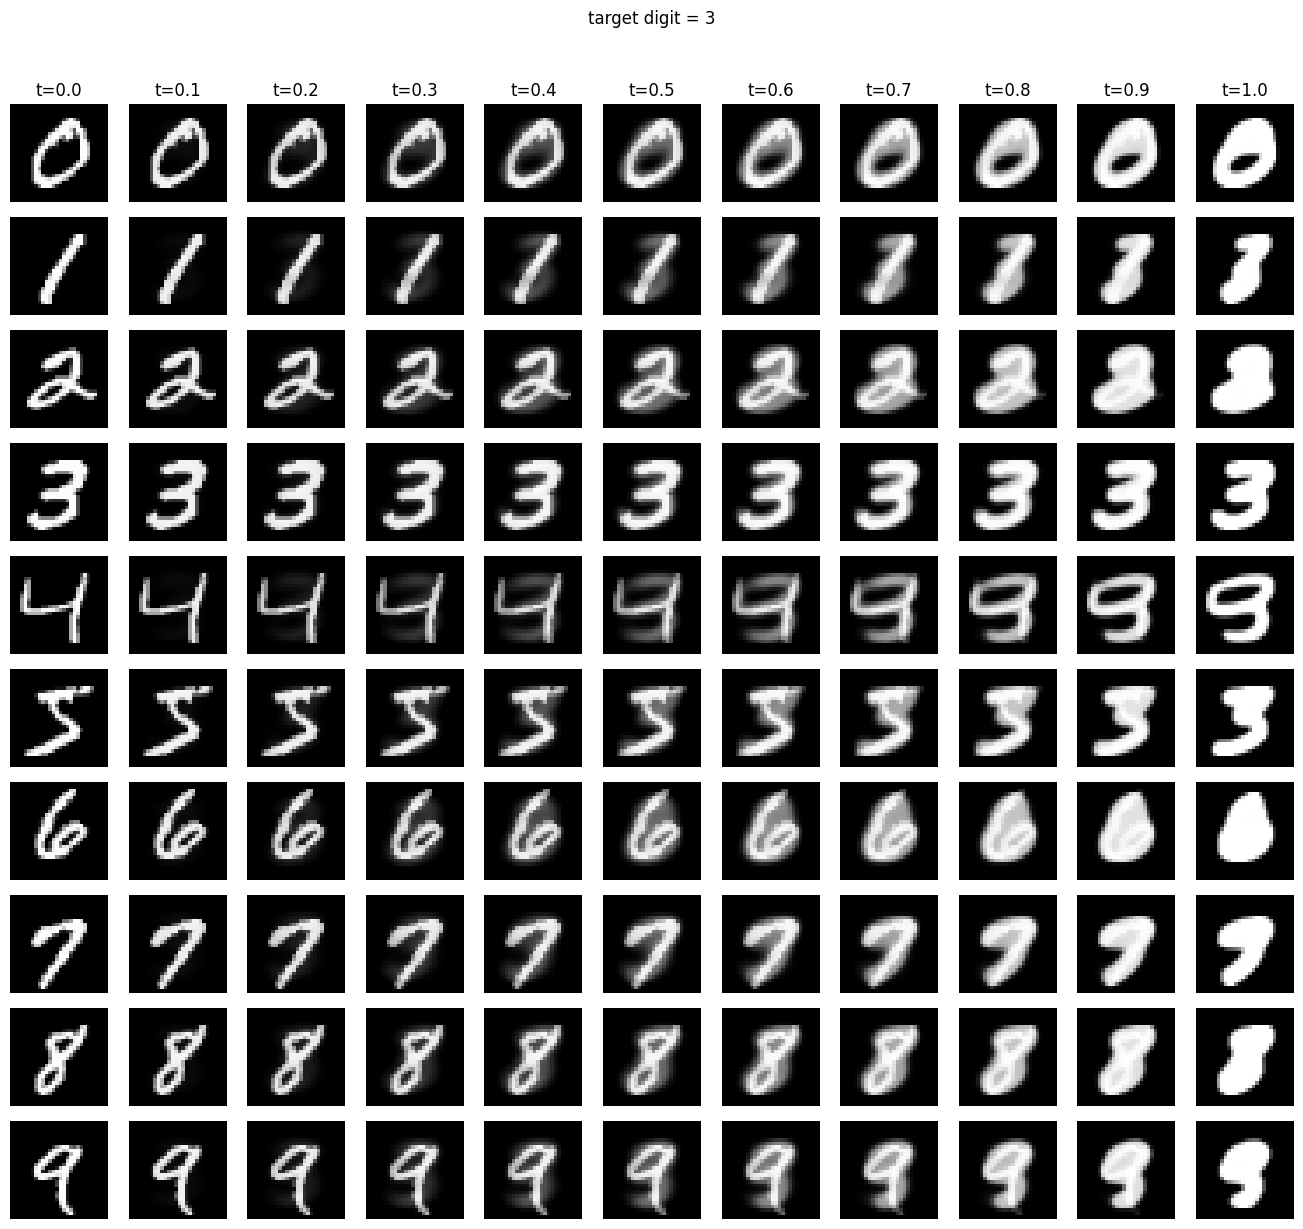

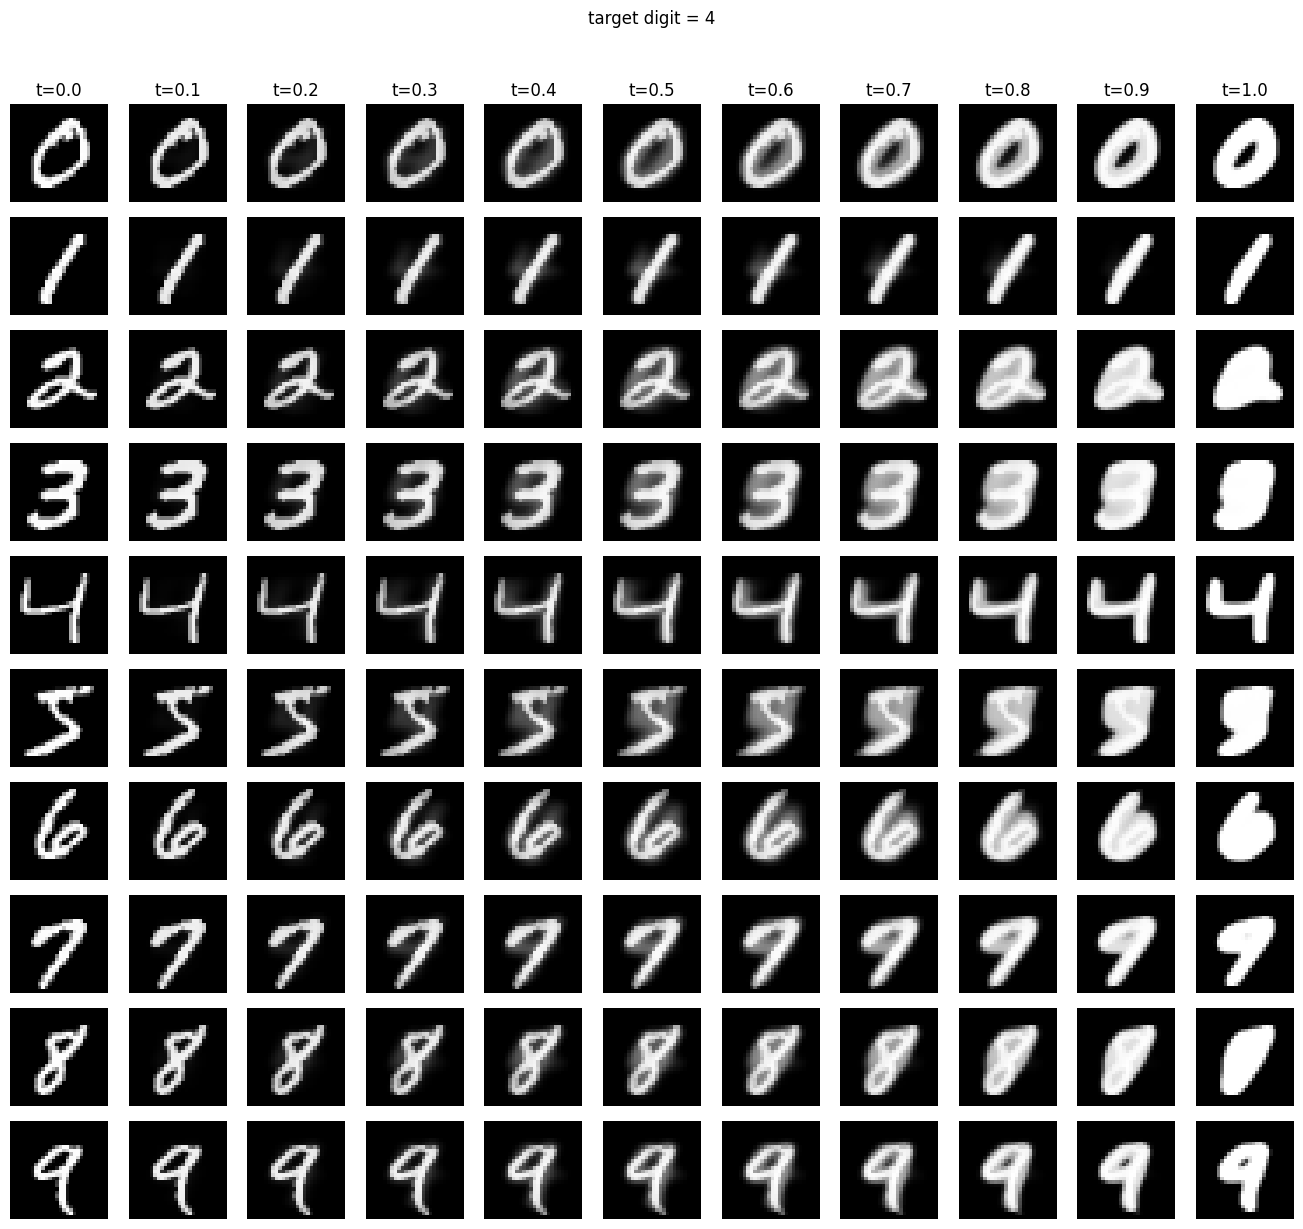

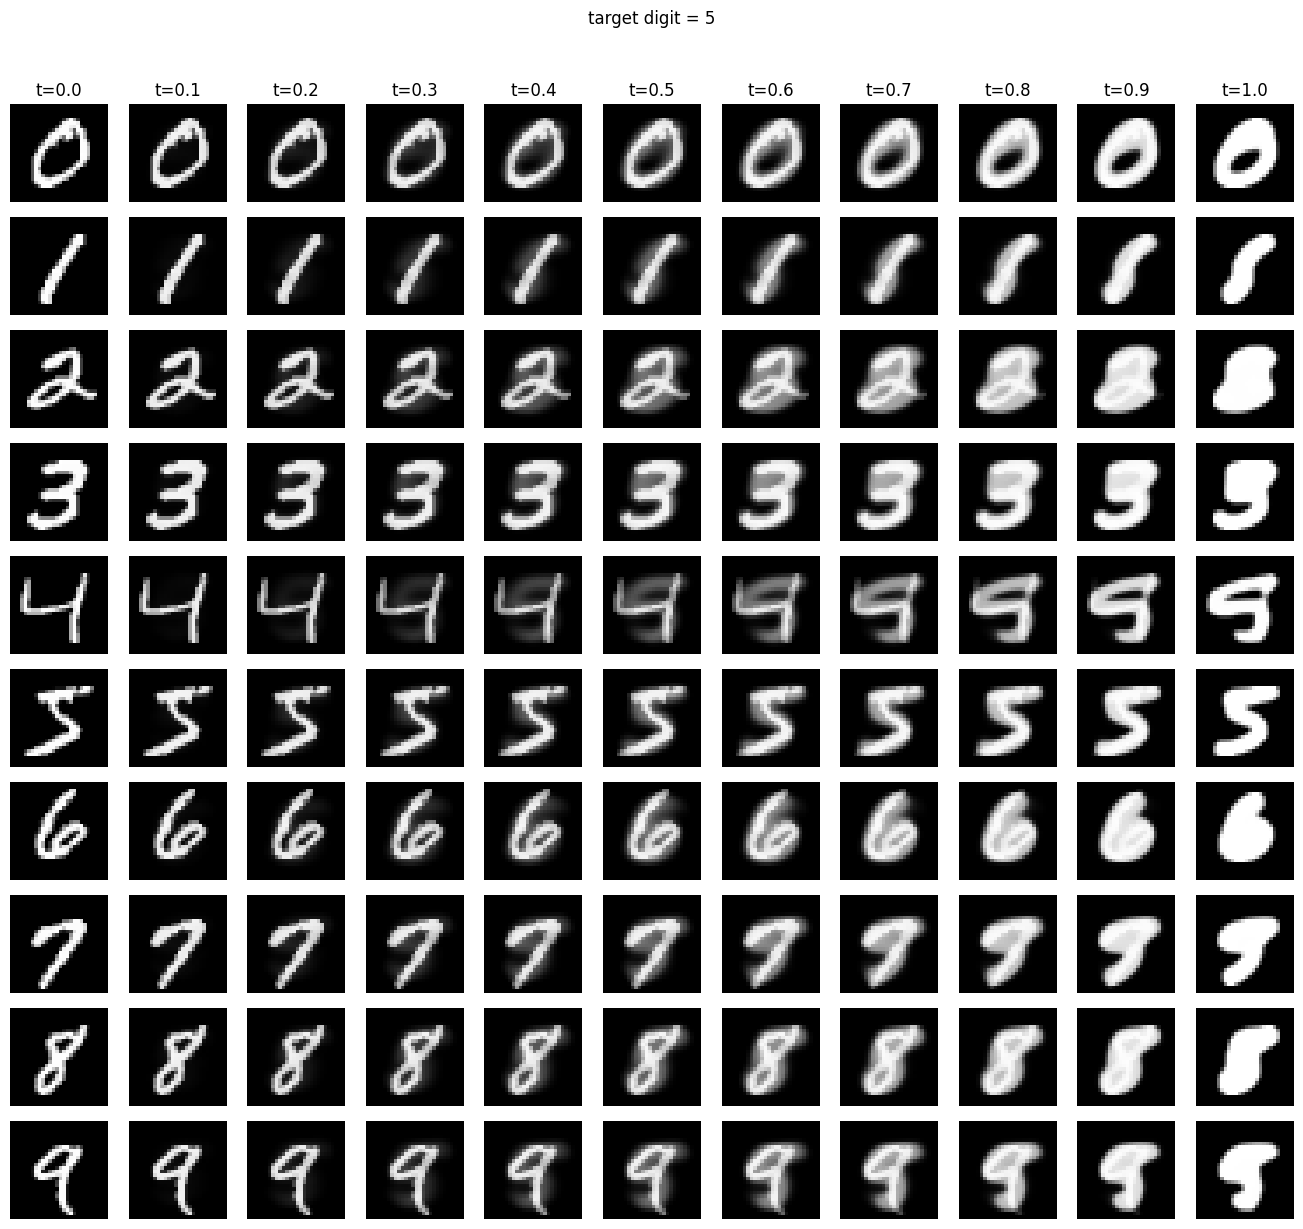

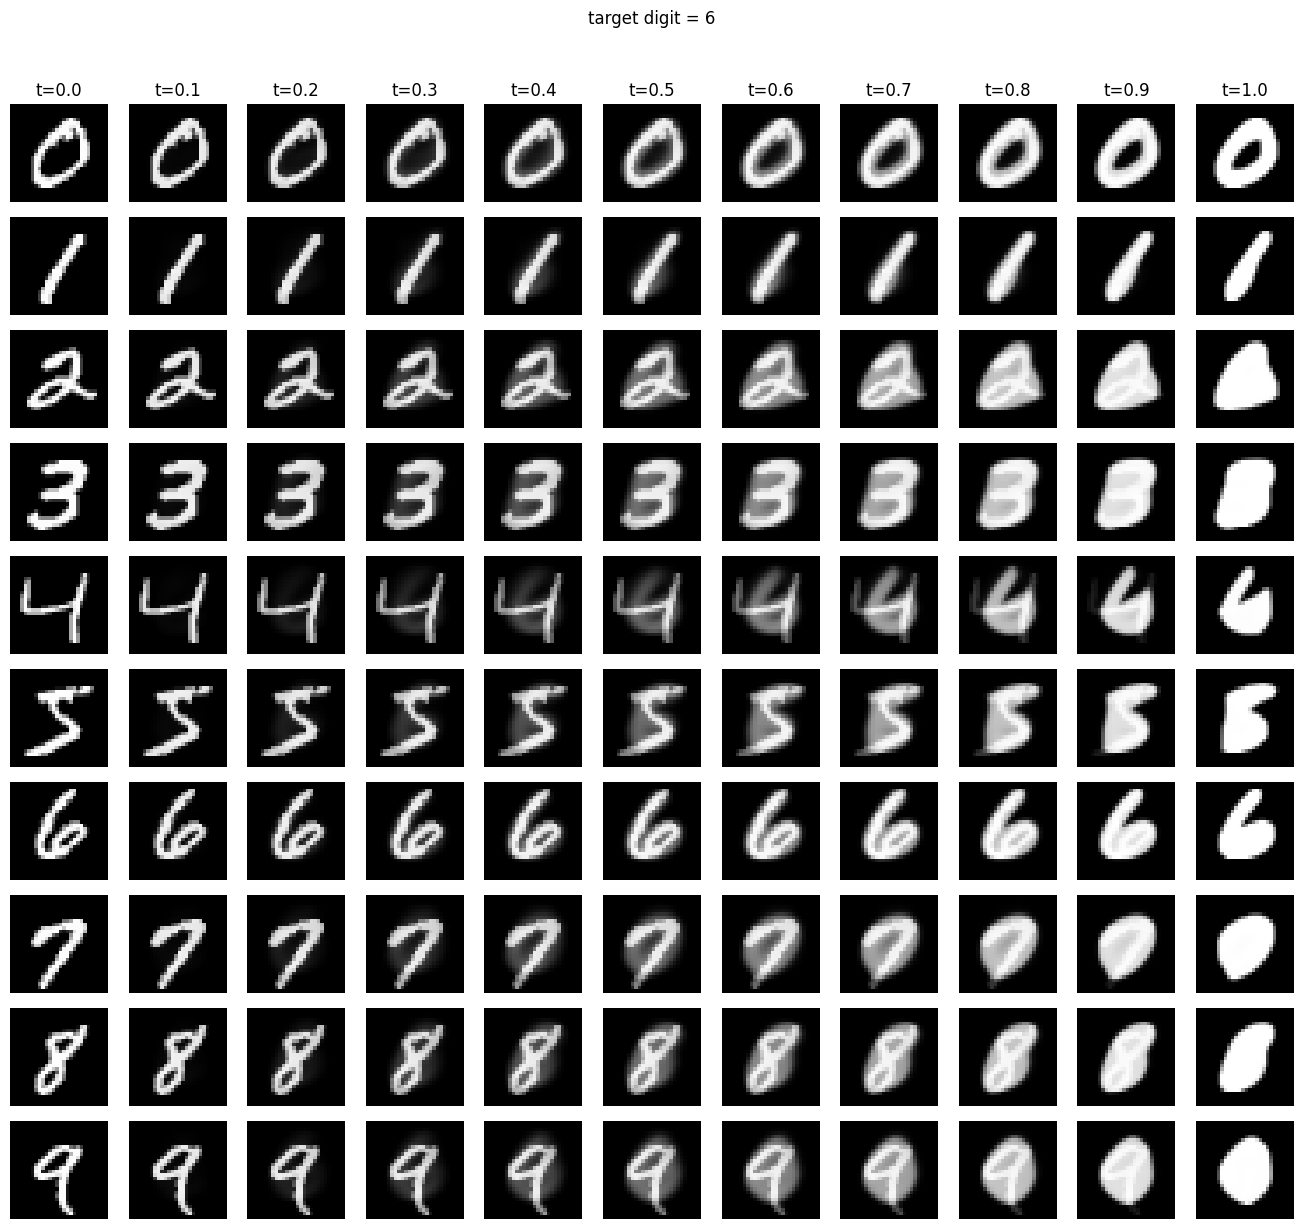

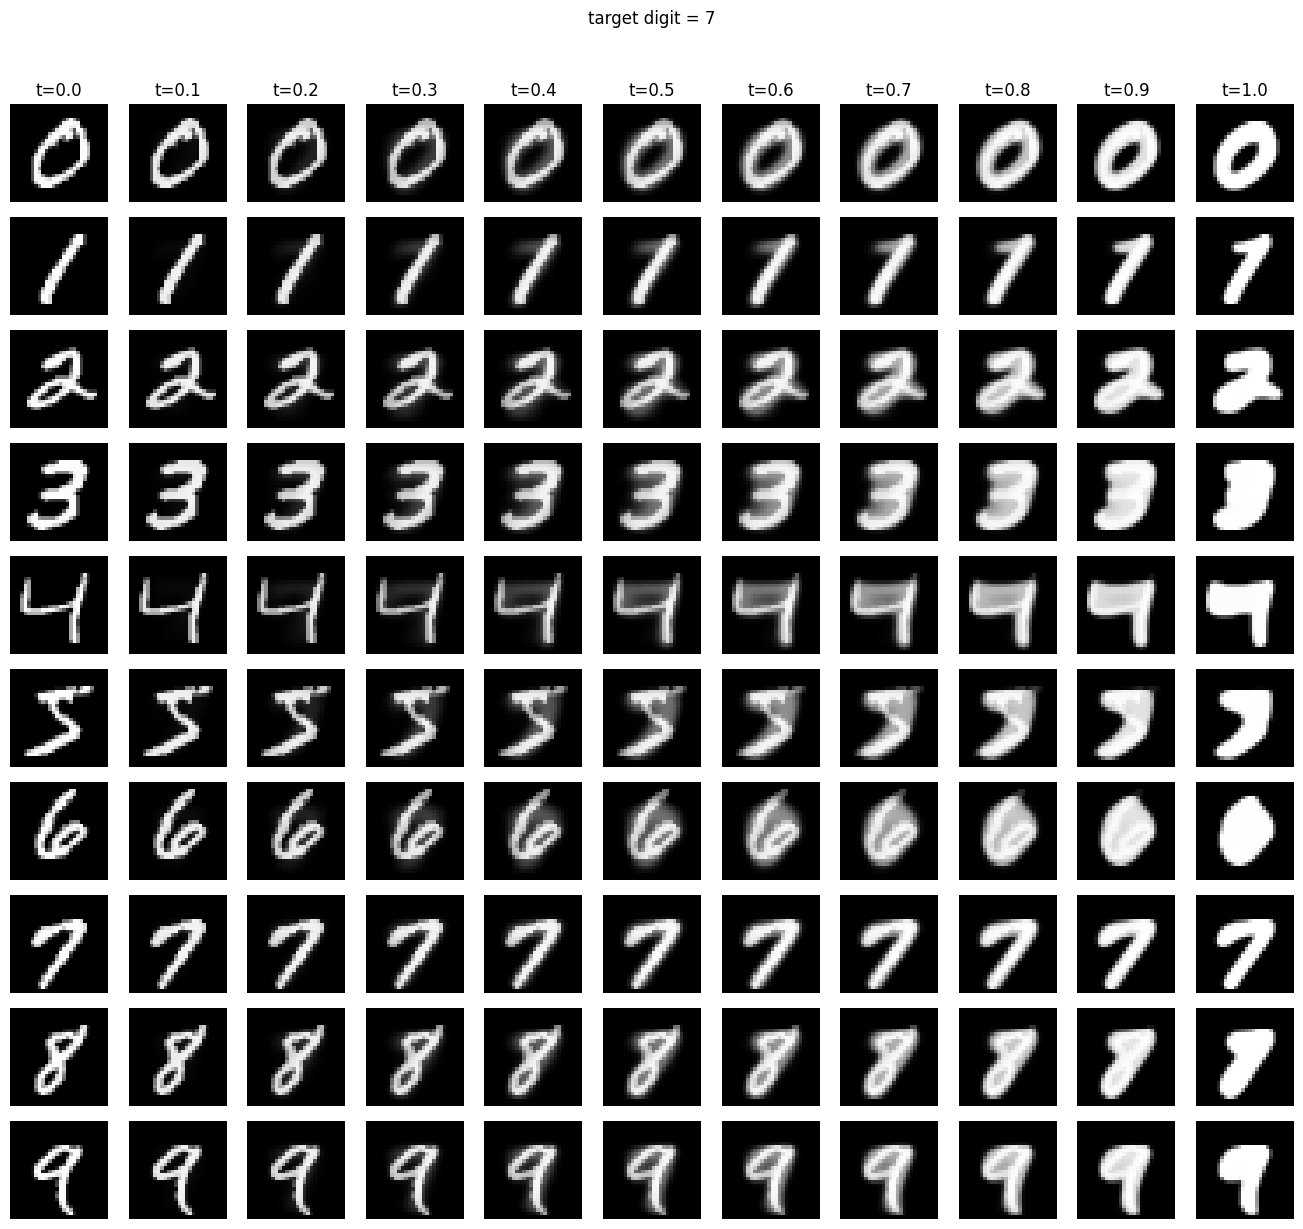

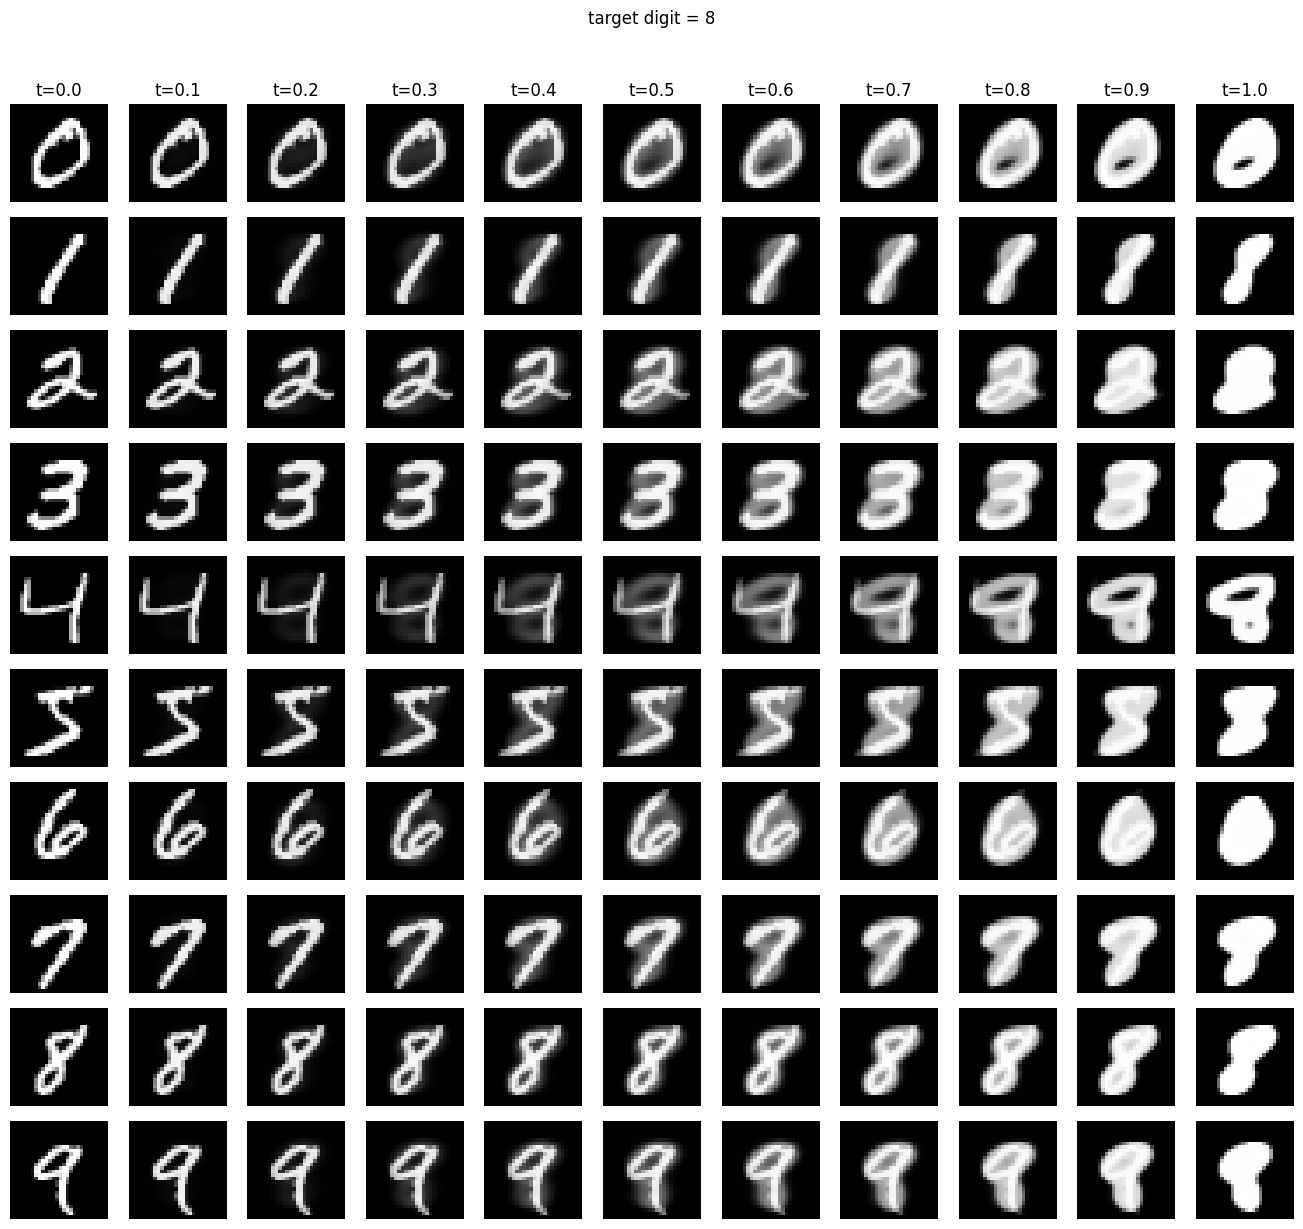

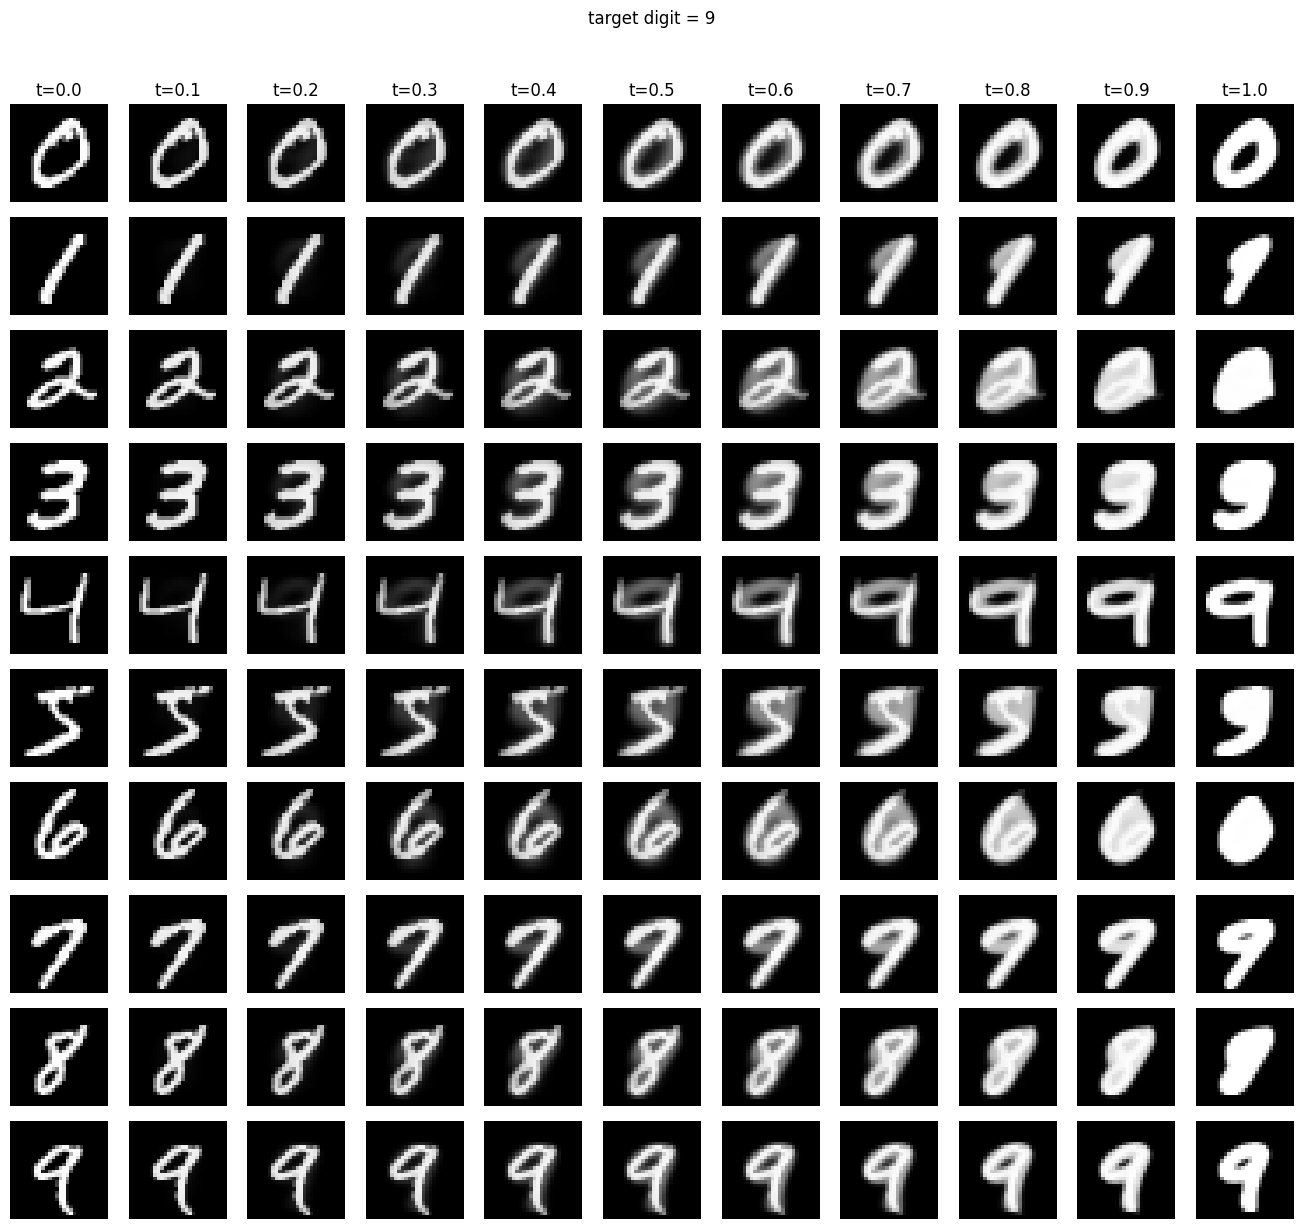

In [11]:
from rectified_flow import RectifiedFlow
from model import MiniUnet
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

checkpoint_path = './checkpoints/v1.1-cfg/miniunet_49.pth'
base_channels = 64
step = 50  # number of Euler steps
cfg_scale = 7.0
device = 'mps'

num_cols = 11
col_times = np.linspace(0.0, 1.0, num_cols)
# capture after these step indices (1..step). we also store the initial state at t=0
capture_after = {int(round(t * step)) for t in col_times[1:]}

# load one real MNIST image for each digit 0-9 as starting figures
mnist = MNIST(root='./data', train=True, download=True, transform=ToTensor())
start_imgs = [None] * 10
for img, label in mnist:
    if start_imgs[label] is None:
        start_imgs[label] = img  # [1, 28, 28]
        if all(x is not None for x in start_imgs):
            break

start_imgs = torch.stack(start_imgs, dim=0).to(device)  # [10, 1, 28, 28]

# load model
model = MiniUnet(base_channels=base_channels)
model.to(device)
model.eval()

# load RectifiedFlow and checkpoint
rf = RectifiedFlow()
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model'])

all_mats = []  # [target_digit][start_digit][time_idx][H][W]
with torch.no_grad():
    for target_digit in range(10):
        rows = []
        y_i = torch.tensor([target_digit], dtype=torch.float32, device=device)
        for start_digit in range(10):
            dt = 1.0 / step
            x_t = start_imgs[start_digit:start_digit + 1].clone()

            snapshots = [x_t.clone()]
            for j in range(step):
                t = torch.tensor([j * dt], device=device)

                # conditional prediction
                v_pred_cond = model(x=x_t, t=t, y=y_i)
                x_t = rf.euler(x_t, v_pred_cond, dt)

                if (j + 1) in capture_after:
                    snapshots.append(x_t.clone())

            # convert snapshots to numpy images in [0, 1]
            row_imgs = [snap[0, 0].clamp(0, 1).cpu().numpy() for snap in snapshots]
            rows.append(row_imgs)

        all_mats.append(rows)

# plot 10 matrices, one per target digit
for target_digit in range(10):
    fig, axes = plt.subplots(10, num_cols, figsize=(num_cols * 1.2, 10 * 1.2))
    for r in range(10):
        for c in range(num_cols):
            ax = axes[r, c]
            ax.imshow(all_mats[target_digit][r][c], cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if r == 0:
                ax.set_title(f't={col_times[c]:.1f}')
            if c == 0:
                ax.set_ylabel(str(r), rotation=0, labelpad=10, va='center')

    fig.suptitle(f'target digit = {target_digit}', y=1.02)
    plt.tight_layout()
    plt.show()